# T8.5 - Hinglish E-Commerce Sentiment Analyzer
### SMAI Assignment 3
K N Akthar, Vanshika Ahlawat \
2023101007, 2023113003


## Pipeline Overview

| # | Section | Description |
|---|---------|-------------|
| 1 | **Setup** | Installs, imports, seeds |
| 2 | **Data Loading** | Load & preview dataset |
| 3 | **EDA** | Class distribution, length, top words |
| 4 | **Word Clouds** | Per-class Hinglish word clouds |
| 5 | **Split** | Stratified 80/10/10 train/val/test |
| 6 | **Baseline** | BART zero-shot (`facebook/bart-large-mnli`) |
| 7 | **Main Model** | Fine-tune `l3cube-pune/hing-bert` |
| 8 | **Upper Bound** | Groq Llama-3 zero-shot (free, no rate limits) |
| 9 | **Evaluation** | Comparison table, confusion matrices |
| 10 | **Error Analysis** | What the model gets wrong and why |
| 11 | **Save** | Export model for Streamlit app |



## 1. Setup & Installs

In [ ]:
!pip install transformers datasets torch scikit-learn -q
!pip install accelerate -q
!pip install wordcloud matplotlib seaborn -q
!pip install groq -q
!pip install nltk -q

print('All packages installed.')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/142.3 kB ? eta -:--:--
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 5.4 MB/s eta 0:00:00
All packages installed.


In [ ]:
import json, random, time, re, os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud, STOPWORDS

import torch
from torch.utils.data import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    pipeline,
    EarlyStoppingCallback
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix
)

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Plotting style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor':   'white',
    'axes.grid':        True,
    'grid.alpha':       0.3,
    'font.size':        11
})
COLORS = {
    'POSITIVE': '#2ecc71',
    'NEGATIVE': '#e74c3c',
    'NEUTRAL':  '#3498db'
}

# Device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device : {device}')
if torch.cuda.is_available():
    print(f'GPU    : {torch.cuda.get_device_name(0)}')
    print(f'Memory : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Device : cuda
GPU    : Tesla T4
Memory : 15.6 GB


## 2. Data Loading

In [ ]:
# Upload data_clean.json
from google.colab import files
print('Upload your datav2.json file:')
uploaded = files.upload()

Upload your datav2.json file:


Saving datav2.json to datav2.json


In [ ]:
with open('datav2.json', 'r', encoding='utf-8') as f:
    raw = json.load(f)

df = pd.DataFrame(raw)

# Label encoding maps
LABEL2ID = {'POSITIVE': 0, 'NEGATIVE': 1, 'NEUTRAL': 2}
ID2LABEL  = {v: k for k, v in LABEL2ID.items()}
CLASS_NAMES = ['POSITIVE', 'NEGATIVE', 'NEUTRAL']

df['label_id']    = df['label'].map(LABEL2ID)
df['word_count']  = df['text'].apply(lambda x: len(x.split()))
df['char_count']  = df['text'].apply(len)

print(f'Total examples : {len(df)}')
print(f'Columns        : {df.columns.tolist()}')
df.head(8)

Total examples : 1048
Columns        : ['text', 'label', 'label_id', 'word_count', 'char_count']


,text,label,label_id,word_count,char_count
0,Samsung Galaxy S24 ka review dena chahta hoon ...,POSITIVE,0,24,122
1,Strap quality decent hai par watch ka dial tho...,NEUTRAL,2,13,71
2,Seriously iPhone 15 se itni umeed nahi thi ki ...,NEGATIVE,1,21,115
3,"Sofa cushion padding is average, long sitting ...",NEUTRAL,2,11,67
4,"Screen guard pe scratches pehle se hi the, ver...",NEGATIVE,1,10,52
5,"Wah, medium size mangaya aur bache ka size bhe...",NEGATIVE,1,17,90
6,Moisturizer quantity thodi kam lagi price ke h...,NEUTRAL,2,9,54
7,Face Serum leke ek dum sahi decision liya. Mer...,POSITIVE,0,19,109


## 3. Exploratory Data Analysis (EDA)

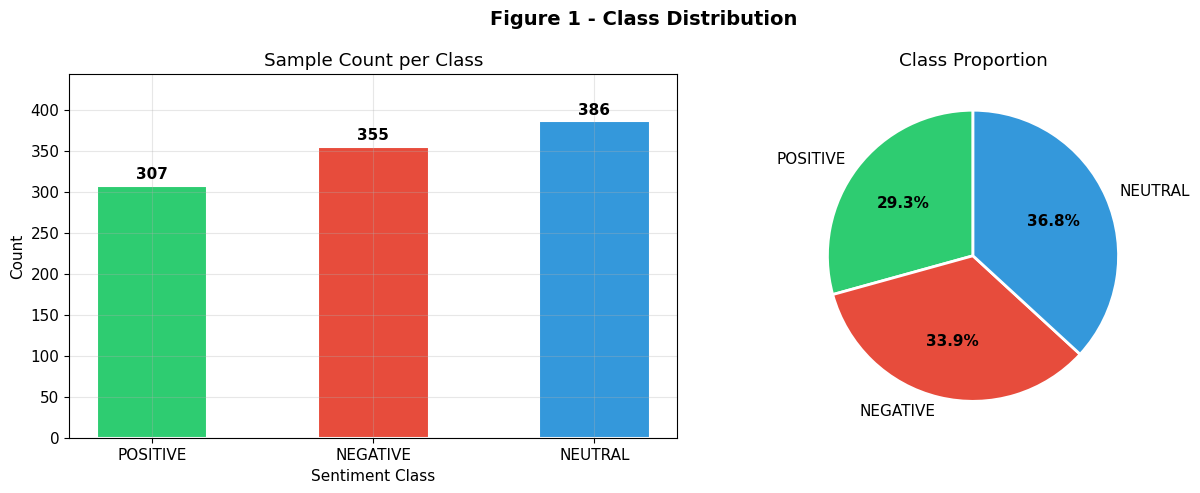

Class counts:
  POSITIVE: 307  (29.3%)
  NEGATIVE: 355  (33.9%)
  NEUTRAL : 386  (36.8%)


In [ ]:
# Figure 1: Class distribution
label_counts = df['label'].value_counts().reindex(CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 1 - Class Distribution', fontsize=14, fontweight='bold')

# Bar chart
bars = axes[0].bar(
    label_counts.index,
    label_counts.values,
    color=[COLORS[l] for l in label_counts.index],
    edgecolor='white', linewidth=1.5, width=0.5
)
for bar, val in zip(bars, label_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 5, str(val),
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_xlabel('Sentiment Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Sample Count per Class')
axes[0].set_ylim(0, label_counts.max() * 1.15)

# Pie chart
wedges, texts, autotexts = axes[1].pie(
    label_counts.values,
    labels=label_counts.index,
    autopct='%1.1f%%',
    colors=[COLORS[l] for l in label_counts.index],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
for at in autotexts:
    at.set_fontweight('bold')
axes[1].set_title('Class Proportion')

plt.tight_layout()
plt.savefig('fig1_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('Class counts:')
for label, count in label_counts.items():
    pct = 100 * count / len(df)
    print(f'  {label:8s}: {count}  ({pct:.1f}%)')

/tmp/ipykernel_624/2866784328.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_to_plot, labels=CLASS_NAMES, patch_artist=True,


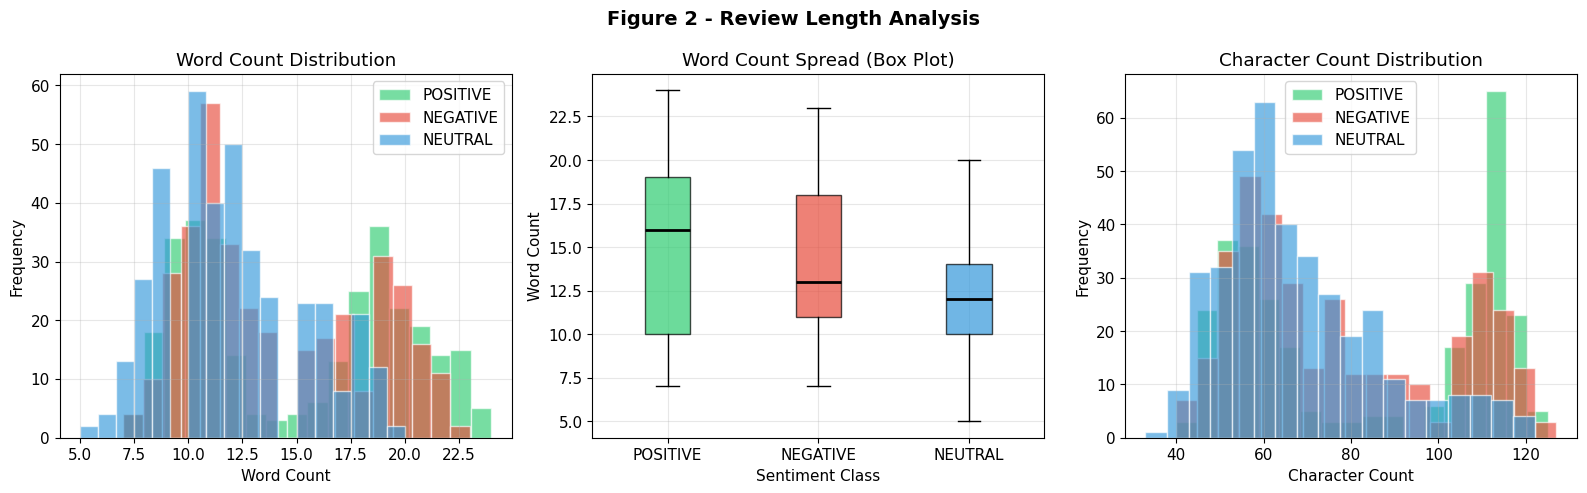

Length statistics:
         word_count                                         char_count        \
              count  mean  std  min   25%   50%   75%   max      count  mean   
label                                                                          
NEGATIVE      355.0  14.1  4.2  7.0  11.0  13.0  18.0  23.0      355.0  77.5   
NEUTRAL       386.0  12.0  3.2  5.0  10.0  12.0  14.0  20.0      386.0  67.6   
POSITIVE      307.0  15.0  5.2  7.0  10.0  16.0  19.0  24.0      307.0  83.6   

                                                
           std   min   25%   50%    75%    max  
label                                           
NEGATIVE  23.6  40.0  58.0  69.0  103.0  127.0  
NEUTRAL   18.2  33.0  55.0  63.0   77.0  122.0  
POSITIVE  27.8  40.0  56.0  82.0  111.5  125.0  


In [ ]:
# Figure 2: Text length analysis
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Figure 2 - Review Length Analysis', fontsize=14, fontweight='bold')

# Word count histogram per class
for label in CLASS_NAMES:
    subset = df[df['label'] == label]['word_count']
    axes[0].hist(subset, bins=18, alpha=0.65,
                 label=label, color=COLORS[label], edgecolor='white')
axes[0].set_xlabel('Word Count')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Word Count Distribution')
axes[0].legend()

# Box plot — word count by class
data_to_plot = [df[df['label'] == l]['word_count'].values for l in CLASS_NAMES]
bp = axes[1].boxplot(data_to_plot, labels=CLASS_NAMES, patch_artist=True,
                     medianprops={'color': 'black', 'linewidth': 2})
for patch, label in zip(bp['boxes'], CLASS_NAMES):
    patch.set_facecolor(COLORS[label])
    patch.set_alpha(0.7)
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Word Count')
axes[1].set_title('Word Count Spread (Box Plot)')

# Character count KDE-like histogram
for label in CLASS_NAMES:
    subset = df[df['label'] == label]['char_count']
    axes[2].hist(subset, bins=18, alpha=0.65,
                 label=label, color=COLORS[label], edgecolor='white')
axes[2].set_xlabel('Character Count')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Character Count Distribution')
axes[2].legend()

plt.tight_layout()
plt.savefig('fig2_length_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# Stats table
print('Length statistics:')
print(df.groupby('label')[['word_count', 'char_count']].describe().round(1))

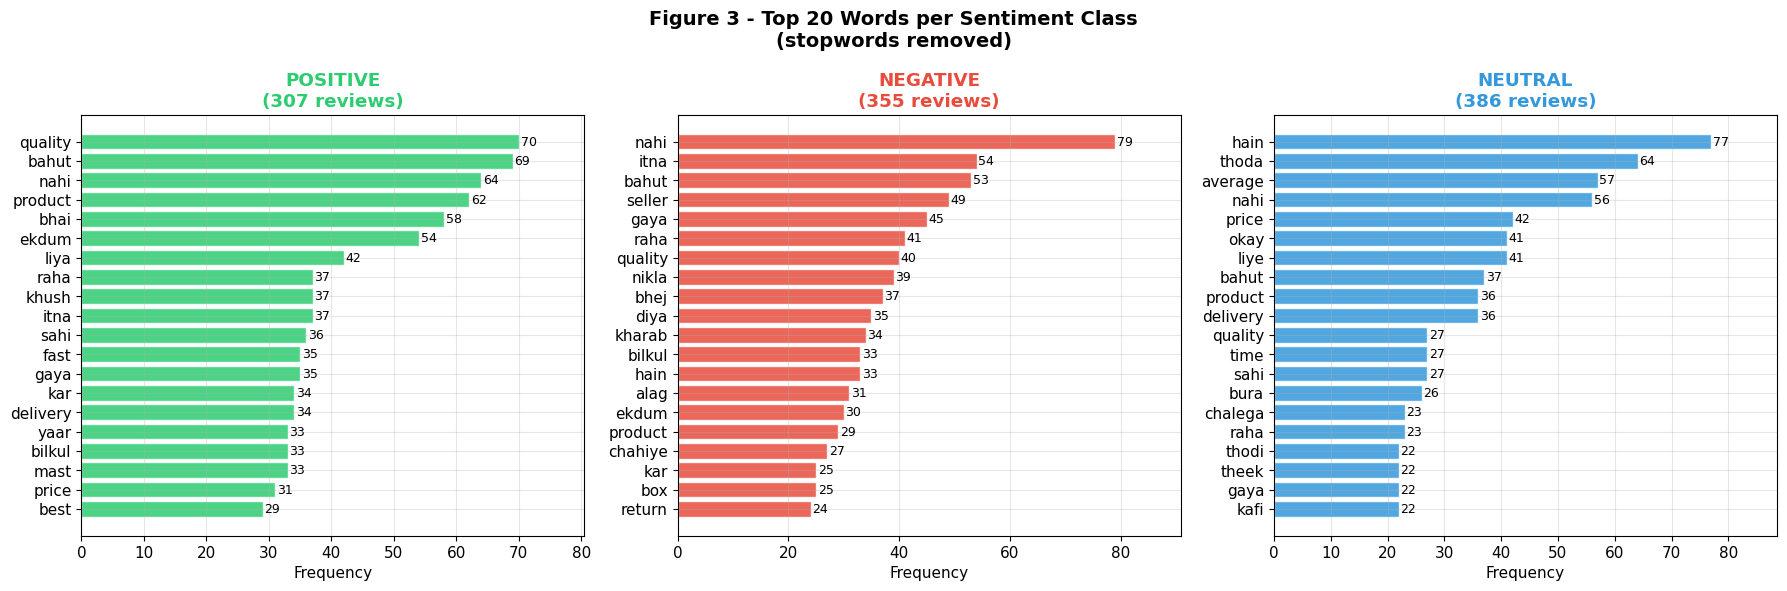

In [ ]:
# Figure 3: Top-20 words per class (bar charts)

# Hinglish stopwords - common filler words to exclude
HINGLISH_STOPWORDS = set([
    'hai', 'ki', 'ka', 'ke', 'ko', 'se', 'ne', 'bhi', 'aur', 'toh',
    'tha', 'thi', 'the', 'ho', 'hoon', 'yeh', 'woh', 'iska', 'unka',
    'mein', 'par', 'pe', 'koi', 'kuch', 'ek', 'is', 'us', 'mere',
    'mera', 'meri', 'hum', 'tum', 'aap', 'ye', 'wo', 'in', 'un',
    'it', 'to', 'is', 'of', 'and', 'a', 'the', 'for', 'on', 'with',
    'this', 'that', 'was', 'are', 'but', 'or', 'an', 'at', 'be',
    'my', 'i', 'so', 'its', 'not', 'very', 'they', 'we', 'from',
    'have', 'has', 'had', 'which', 'when', 'what', 'also', 'if',
    'by', 'as', 'can', 'he', 'she', 'it', 'do', 'did', 'does'
])

def get_top_words(texts, n=20):
    all_words = []
    for text in texts:
        words = re.findall(r'[a-zA-Z\u0900-\u097F]+', text.lower())
        words = [w for w in words
                 if w not in HINGLISH_STOPWORDS and len(w) > 2]
        all_words.extend(words)
    return Counter(all_words).most_common(n)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Figure 3 - Top 20 Words per Sentiment Class\n(stopwords removed)',
             fontsize=14, fontweight='bold')

for ax, label in zip(axes, CLASS_NAMES):
    texts_subset = df[df['label'] == label]['text'].tolist()
    top_words    = get_top_words(texts_subset, n=20)
    words, counts = zip(*top_words)

    bars = ax.barh(list(reversed(words)), list(reversed(counts)),
                   color=COLORS[label], alpha=0.85, edgecolor='white')
    ax.set_title(f'{label}\n({len(texts_subset)} reviews)',
                 fontweight='bold', color=COLORS[label])
    ax.set_xlabel('Frequency')
    ax.set_xlim(0, max(counts) * 1.15)
    for bar, count in zip(bars, list(reversed(counts))):
        ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
                str(count), va='center', fontsize=9)

plt.tight_layout()
plt.savefig('fig3_top_words.png', dpi=150, bbox_inches='tight')
plt.show()


## 4. Word Clouds - Per Sentiment Class

Word clouds visualise the most frequent terms in each class. Larger = more frequent.
We generate one cloud per sentiment class with class-matched colours.

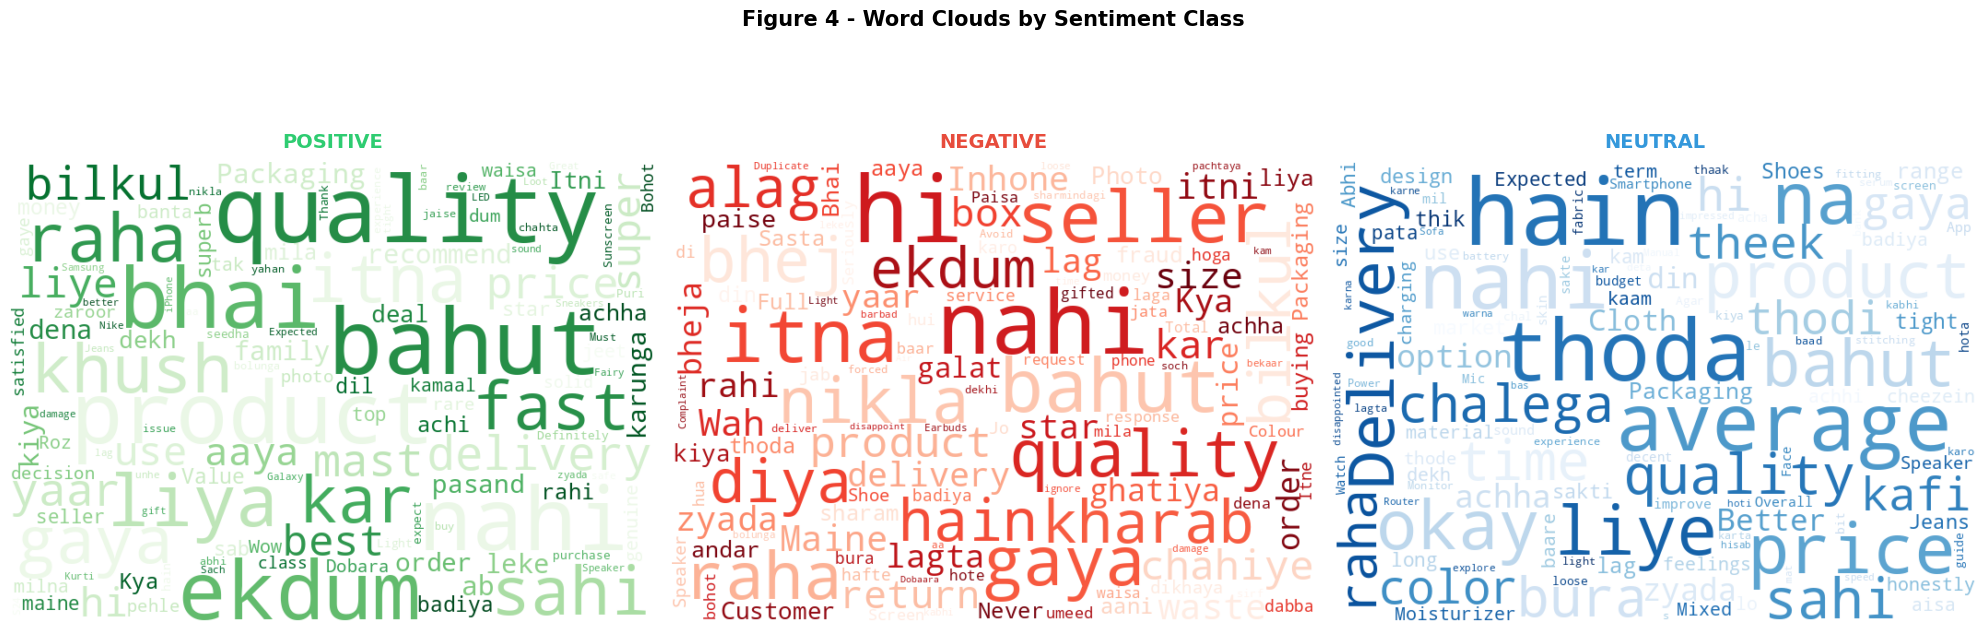

In [ ]:
# Figure 4: Word Clouds

WC_COLORMAPS = {
    'POSITIVE': 'Greens',
    'NEGATIVE': 'Reds',
    'NEUTRAL':  'Blues'
}

WC_STOPWORDS = STOPWORDS.union(HINGLISH_STOPWORDS)

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
fig.suptitle('Figure 4 - Word Clouds by Sentiment Class',
             fontsize=15, fontweight='bold', y=1.02)

for ax, label in zip(axes, CLASS_NAMES):
    text_blob = ' '.join(df[df['label'] == label]['text'].tolist())

    # Clean punctuation
    text_blob = re.sub(r'[^\w\s]', ' ', text_blob)

    wc = WordCloud(
        width=700,
        height=500,
        background_color='white',
        colormap=WC_COLORMAPS[label],
        stopwords=WC_STOPWORDS,
        max_words=120,
        min_font_size=8,
        max_font_size=100,
        collocations=False,  # Avoid duplicate bigrams
        random_state=SEED
    ).generate(text_blob)

    ax.imshow(wc, interpolation='bilinear')
    ax.axis('off')
    ax.set_title(f'{label}',
                 fontsize=14, fontweight='bold',
                 color=COLORS[label], pad=10)

    # Add subtle border in class color
    for spine in ax.spines.values():
        spine.set_edgecolor(COLORS[label])
        spine.set_linewidth(3)
        spine.set_visible(True)

plt.tight_layout()
plt.savefig('fig4_wordclouds.png', dpi=150, bbox_inches='tight')
plt.show()
# print('Word clouds saved to fig4_wordclouds.png')

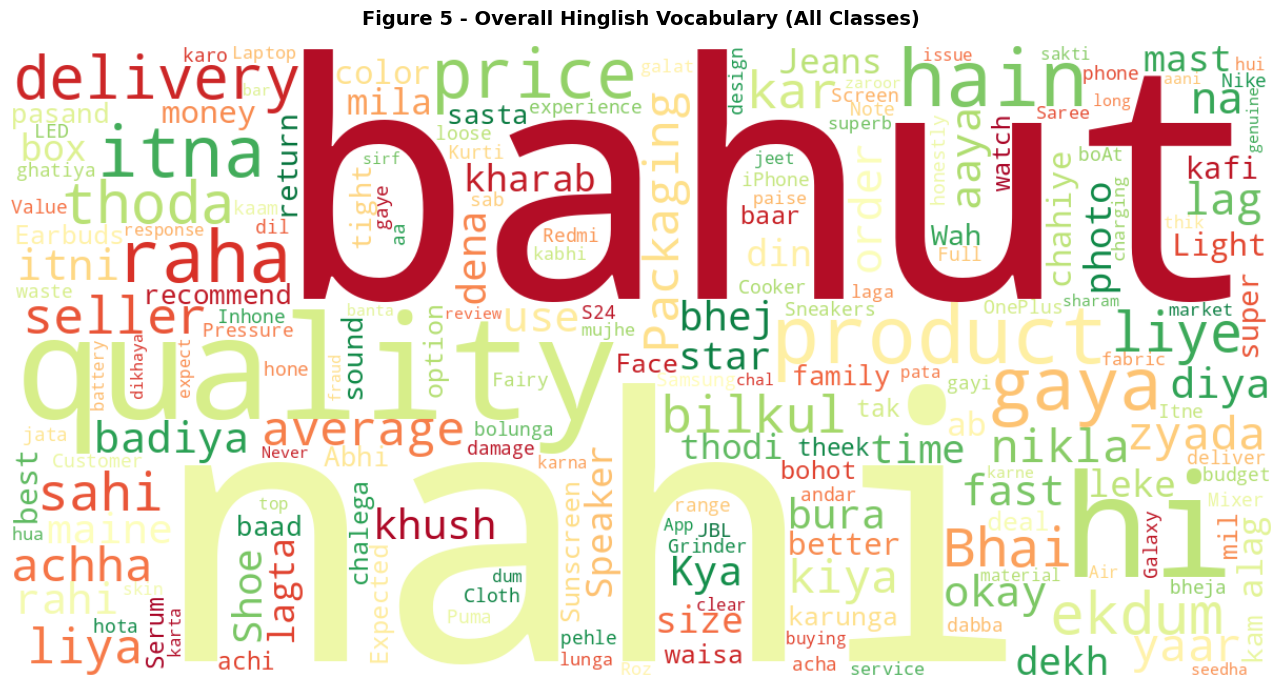

In [ ]:
# Figure 5: Combined overall word cloud
all_text = ' '.join(df['text'].tolist())
all_text = re.sub(r'[^\w\s]', ' ', all_text)

wc_all = WordCloud(
    width=1200, height=600,
    background_color='white',
    colormap='RdYlGn',
    stopwords=WC_STOPWORDS,
    max_words=200,
    collocations=False,
    random_state=SEED
).generate(all_text)

fig, ax = plt.subplots(figsize=(16, 7))
ax.imshow(wc_all, interpolation='bilinear')
ax.axis('off')
ax.set_title('Figure 5 - Overall Hinglish Vocabulary (All Classes)',
             fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.savefig('fig5_wordcloud_overall.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Train / Val / Test Split
Split: 80-10-10

Train :  838 samples  |  Class dist: Counter({2: 309, 1: 284, 0: 245})
Val   :  105 samples  |  Class dist: Counter({2: 39, 1: 35, 0: 31})
Test  :  105 samples  |  Class dist: Counter({2: 38, 1: 36, 0: 31})


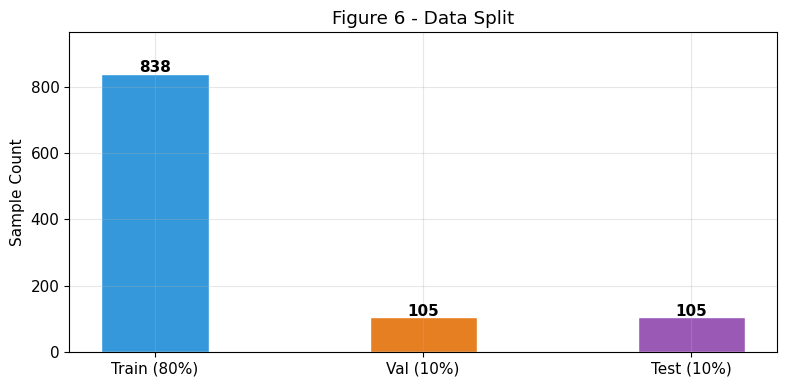

In [ ]:
texts = df['text'].tolist()
labels = df['label_id'].tolist()

# Stratified 80 / 10 / 10
X_train, X_temp, y_train, y_temp = train_test_split(
    texts, labels, test_size=0.2, random_state=SEED, stratify=labels
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.5, random_state=SEED, stratify=y_temp
)

print(f'Train : {len(X_train):4d} samples  |  Class dist: {Counter(y_train)}')
print(f'Val   : {len(X_val):4d} samples  |  Class dist: {Counter(y_val)}')
print(f'Test  : {len(X_test):4d} samples  |  Class dist: {Counter(y_test)}')

# Visualise split
fig, ax = plt.subplots(figsize=(8, 4))
split_names = ['Train (80%)', 'Val (10%)', 'Test (10%)']
split_sizes = [len(X_train), len(X_val), len(X_test)]
bars = ax.bar(split_names, split_sizes, color=['#3498db', '#e67e22', '#9b59b6'],
              width=0.4, edgecolor='white')
for bar, val in zip(bars, split_sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Figure 6 - Data Split')
ax.set_ylabel('Sample Count')
ax.set_ylim(0, max(split_sizes) * 1.15)
plt.tight_layout()
plt.savefig('fig6_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Baseline - BART Zero-Shot

`facebook/bart-large-mnli` - no training, no labels needed.  
This is our **lower bound** to compare against.

In [ ]:
print('Loading BART zero-shot classifier...')
bart_clf = pipeline(
    'zero-shot-classification',
    model='facebook/bart-large-mnli',
    device=0 if torch.cuda.is_available() else -1
)

# UPDATED labels (better semantics)
CANDIDATE_LABELS = [
    'a positive sentiment',
    'a negative sentiment',
    'a neutral or mixed sentiment'
]

# label map
BART_LABEL_MAP = {
    'a positive sentiment': 0,
    'a negative sentiment': 1,
    'a neutral or mixed sentiment': 2
}

def predict_bart_batch(texts, batch_size=32):
    preds = []
    for i in range(0, len(texts), batch_size):
        batch = texts[i:i+batch_size]

        # hypothesis template + batch_size
        results = bart_clf(
            batch,
            CANDIDATE_LABELS,
            hypothesis_template="This text expresses {}.",
            batch_size=batch_size
        )

        for r in results:
            # use scores for better neutral handling
            scores = dict(zip(r['labels'], r['scores']))

            if scores['a neutral or mixed sentiment'] > 0.4:
                preds.append(2)
            else:
                preds.append(BART_LABEL_MAP[r['labels'][0]])

        if i % 64 == 0:
            print(f'  BART: {min(i+batch_size, len(texts))}/{len(texts)}', end='\r')

    print()
    return preds

print('Running BART on test set...')
bart_preds = predict_bart_batch(X_test)

bart_acc = accuracy_score(y_test, bart_preds)
bart_f1  = f1_score(y_test, bart_preds, average='macro')

print(f'\nBART Zero-Shot  ->  Accuracy: {bart_acc:.4f}  |  Macro F1: {bart_f1:.4f}')
print()
print(classification_report(y_test, bart_preds, target_names=CLASS_NAMES))

Loading BART zero-shot classifier...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Running BART on test set...


BART Zero-Shot  ->  Accuracy: 0.6667  |  Macro F1: 0.6571

              precision    recall  f1-score   support

    POSITIVE       0.63      0.77      0.70        31
    NEGATIVE       0.76      0.44      0.56        36
     NEUTRAL       0.65      0.79      0.71        38

    accuracy                           0.67       105
   macro avg       0.68      0.67      0.66       105
weighted avg       0.68      0.67      0.66       105



## 7. Main Model - Fine-Tune `l3cube-pune/hing-bert`

HingBERT is a BERT model **pre-trained on Hinglish** text from L3Cube.  
We add a 3-class classification head and fine-tune for 5 epochs.

In [ ]:
MODEL_NAME = 'l3cube-pune/hing-bert'
MAX_LEN    = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class HinglishDataset(Dataset):
    """PyTorch Dataset for Hinglish reviews."""

    def __init__(self, texts, labels, tokenizer, max_len=MAX_LEN):
        self.texts     = texts
        self.labels    = labels
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids':      enc['input_ids'].squeeze(),
            'attention_mask': enc['attention_mask'].squeeze(),
            'labels':         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_ds = HinglishDataset(X_train, y_train, tokenizer)
val_ds   = HinglishDataset(X_val,   y_val,   tokenizer)
test_ds  = HinglishDataset(X_test,  y_test,  tokenizer)

print(f'Train dataset : {len(train_ds)} samples')
print(f'Val   dataset : {len(val_ds)} samples')
print(f'Test  dataset : {len(test_ds)} samples')

# Sanity check one sample
s = train_ds[0]
print(f'\nSample input_ids shape : {s["input_ids"].shape}')

Train dataset : 838 samples
Val   dataset : 105 samples
Test  dataset : 105 samples

Sample input_ids shape : torch.Size([128])


In [ ]:
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=ID2LABEL,
    label2id=LABEL2ID
).to(device)

total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params     : {total:,}')
print(f'Trainable params : {trainable:,}')

BertForSequenceClassification LOAD REPORT from: l3cube-pune/hing-bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.weight                   | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training

Total params     : 109,484,547
Trainable params : 109,484,547


In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {
        'accuracy':    accuracy_score(labels, preds),
        'macro_f1':    f1_score(labels, preds, average='macro'),
        'weighted_f1': f1_score(labels, preds, average='weighted')
    }

In [ ]:
training_args = TrainingArguments(
    output_dir                  = './hing-bert-sentiment',
    num_train_epochs            = 5,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio                = 0.1,
    weight_decay                = 0.01,
    learning_rate               = 2e-5,
    eval_strategy               = 'epoch',
    save_strategy               = 'epoch',
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'macro_f1',
    greater_is_better           = True,
    logging_steps               = 20,
    fp16                        = torch.cuda.is_available(),
    seed                        = SEED,
    report_to                   = 'none'
)

trainer = Trainer(
    model         = model,
    args          = training_args,
    train_dataset = train_ds,
    eval_dataset  = val_ds,
    compute_metrics = compute_metrics,
    callbacks     = [EarlyStoppingCallback(early_stopping_patience=2)]
)

print('Training config ready.')

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training config ready.


In [ ]:
print('Starting fine-tuning...')
train_result = trainer.train()
print(f'\nTraining complete  |  Final train loss: {train_result.training_loss:.4f}')

Starting fine-tuning...


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,1.067799,0.810147,0.771429,0.763077,0.766125
2,0.762417,0.327232,0.876190,0.875627,0.876378
3,0.262032,0.359358,0.866667,0.866473,0.867247
4,0.174469,0.327735,0.885714,0.884552,0.885851
5,0.107996,0.335688,0.876190,0.875126,0.875980


There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Training complete  |  Final train loss: 0.4139


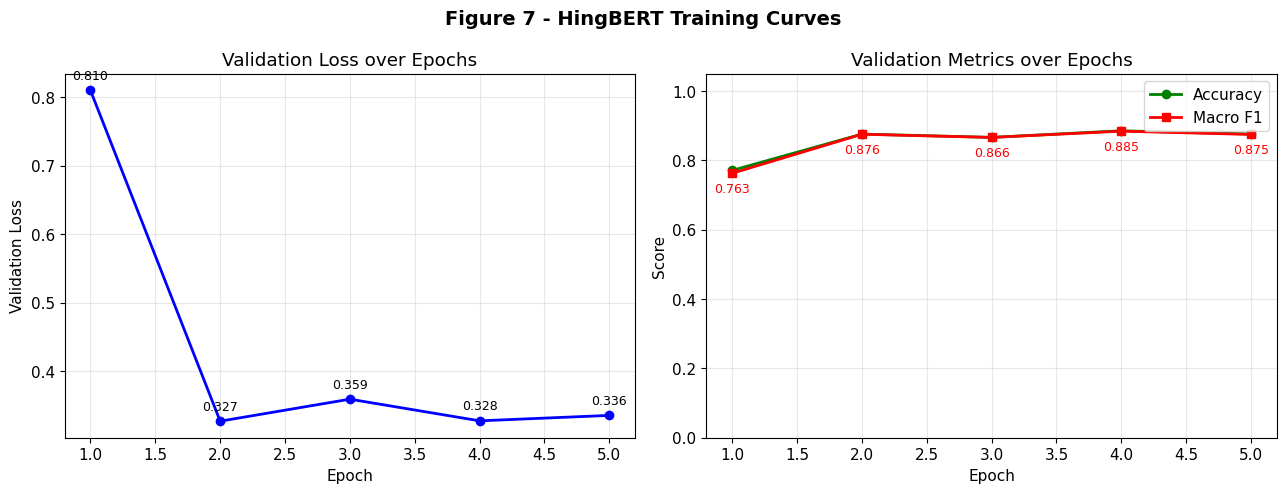

In [ ]:
# Figure 7: Training curves
log_history = trainer.state.log_history

eval_records = [e for e in log_history if 'eval_loss' in e]
epochs_list  = [e['epoch']            for e in eval_records]
eval_losses  = [e['eval_loss']        for e in eval_records]
eval_f1s     = [e['eval_macro_f1']    for e in eval_records]
eval_accs    = [e['eval_accuracy']    for e in eval_records]

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 7 - HingBERT Training Curves', fontsize=14, fontweight='bold')

axes[0].plot(epochs_list, eval_losses, 'b-o', linewidth=2, markersize=6)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Validation Loss')
axes[0].set_title('Validation Loss over Epochs')
for x, y in zip(epochs_list, eval_losses):
    axes[0].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, 8), ha='center', fontsize=9)

axes[1].plot(epochs_list, eval_accs, 'g-o', linewidth=2, markersize=6, label='Accuracy')
axes[1].plot(epochs_list, eval_f1s,  'r-s', linewidth=2, markersize=6, label='Macro F1')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Score')
axes[1].set_title('Validation Metrics over Epochs')
axes[1].legend()
axes[1].set_ylim(0, 1.05)
for x, y in zip(epochs_list, eval_f1s):
    axes[1].annotate(f'{y:.3f}', (x, y), textcoords='offset points',
                     xytext=(0, -14), ha='center', fontsize=9, color='red')

plt.tight_layout()
plt.savefig('fig7_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print('Evaluating HingBERT on held-out test set...')
test_output    = trainer.predict(test_ds)
hingbert_preds = np.argmax(test_output.predictions, axis=1)
hingbert_probs = torch.softmax(torch.tensor(test_output.predictions), dim=1).numpy()

hingbert_acc = accuracy_score(y_test, hingbert_preds)
hingbert_f1  = f1_score(y_test, hingbert_preds, average='macro')

print(f'\nHingBERT Fine-tuned  ->  Accuracy: {hingbert_acc:.4f}  |  Macro F1: {hingbert_f1:.4f}')
print()
print(classification_report(y_test, hingbert_preds, target_names=CLASS_NAMES))

Evaluating HingBERT on held-out test set...



HingBERT Fine-tuned  ->  Accuracy: 0.9238  |  Macro F1: 0.9233

              precision    recall  f1-score   support

    POSITIVE       0.91      0.94      0.92        31
    NEGATIVE       0.94      0.89      0.91        36
     NEUTRAL       0.92      0.95      0.94        38

    accuracy                           0.92       105
   macro avg       0.92      0.92      0.92       105
weighted avg       0.92      0.92      0.92       105



## 8. Upper Bound - Groq Llama-3 Zero-Shot

We run this on a **100-sample stratified subset** of the test set.

In [ ]:
from groq import Groq

GROQ_API_KEY = 'GROQ_API_KEY'

groq_client = Groq(api_key=GROQ_API_KEY)

GROQ_SYSTEM = """You are a sentiment classifier for Hinglish (Hindi+English code-mixed) \
e-commerce product reviews from Indian platforms like Flipkart and Meesho.
You must classify each review as exactly one of: POSITIVE, NEGATIVE, or NEUTRAL.
Reply with only the single word label. No explanation, no punctuation."""

def predict_groq(text, retries=3):
    for attempt in range(retries):
        try:
            response = groq_client.chat.completions.create(
                model='llama-3.3-70b-versatile',
                messages=[
                    {'role': 'system',  'content': GROQ_SYSTEM},
                    {'role': 'user',    'content': f'Review: {text}'}
                ],
                temperature=0,
                max_tokens=5
            )
            raw = response.choices[0].message.content.strip().upper()
            for label in ['POSITIVE', 'NEGATIVE', 'NEUTRAL']:
                if label in raw:
                    return LABEL2ID[label]
            return LABEL2ID['NEUTRAL']  # fallback
        except Exception as e:
            if attempt < retries - 1:
                time.sleep(1)
            else:
                print(f'  Groq error: {e}')
                return LABEL2ID['NEUTRAL']

# Stratified 100-sample subset
GROQ_N = 100
X_groq, _, y_groq, _ = train_test_split(
    X_test, y_test, train_size=GROQ_N,
    random_state=SEED, stratify=y_test
)

print(f'Running Groq Llama-3 on {GROQ_N} examples...')
groq_preds = []
for i, text in enumerate(X_groq):
    pred = predict_groq(text)
    groq_preds.append(pred)
    if (i+1) % 10 == 0:
        print(f'  {i+1}/{GROQ_N} done')

groq_acc = accuracy_score(y_groq, groq_preds)
groq_f1  = f1_score(y_groq, groq_preds, average='macro')

print(f'\nGroq Llama-3 Zero-Shot (n={GROQ_N})  →  Accuracy: {groq_acc:.4f}  |  Macro F1: {groq_f1:.4f}')
print()
print(classification_report(y_groq, groq_preds, target_names=CLASS_NAMES))

Running Groq Llama-3 on 100 examples...
  10/100 done
  20/100 done
  30/100 done
  40/100 done
  50/100 done
  60/100 done
  70/100 done
  80/100 done
  90/100 done
  100/100 done

Groq Llama-3 Zero-Shot (n=100)  →  Accuracy: 0.9200  |  Macro F1: 0.9190

              precision    recall  f1-score   support

    POSITIVE       0.88      1.00      0.94        30
    NEGATIVE       0.89      1.00      0.94        34
     NEUTRAL       1.00      0.78      0.88        36

    accuracy                           0.92       100
   macro avg       0.93      0.93      0.92       100
weighted avg       0.93      0.92      0.92       100



## 9. Evaluation - Comparison Table & Confusion Matrices

In [ ]:
# Comparison table
results_df = pd.DataFrame({
    'Model':            ['BART Zero-Shot',
                         'HingBERT Fine-tuned',
                         f'Groq Llama-3 (n={GROQ_N})'],
    'Accuracy':         [bart_acc,     hingbert_acc,  groq_acc],
    'Macro F1':         [bart_f1,      hingbert_f1,   groq_f1],
    'Training':         ['None',       '~5 min (T4)', 'None (API)'],
    'Eval on n':        [len(X_test),  len(X_test),   GROQ_N],
    'Cost':             ['Free',       'Free (Colab)', 'Free tier'],
})

# Format floats
for col in ['Accuracy', 'Macro F1']:
    results_df[col] = results_df[col].apply(lambda x: f'{x:.4f}')

print('═' * 75)
print('MODEL COMPARISON -- ABLATION TABLE')
print('═' * 75)
print(results_df.to_string(index=False))
print('═' * 75)

results_df.to_csv('model_comparison.csv', index=False)
print('Saved -> model_comparison.csv')

═══════════════════════════════════════════════════════════════════════════
MODEL COMPARISON -- ABLATION TABLE
═══════════════════════════════════════════════════════════════════════════
               Model Accuracy Macro F1    Training  Eval on n         Cost
      BART Zero-Shot   0.6667   0.6571        None        105         Free
 HingBERT Fine-tuned   0.9238   0.9233 ~5 min (T4)        105 Free (Colab)
Groq Llama-3 (n=100)   0.9200   0.9190  None (API)        100    Free tier
═══════════════════════════════════════════════════════════════════════════
Saved -> model_comparison.csv


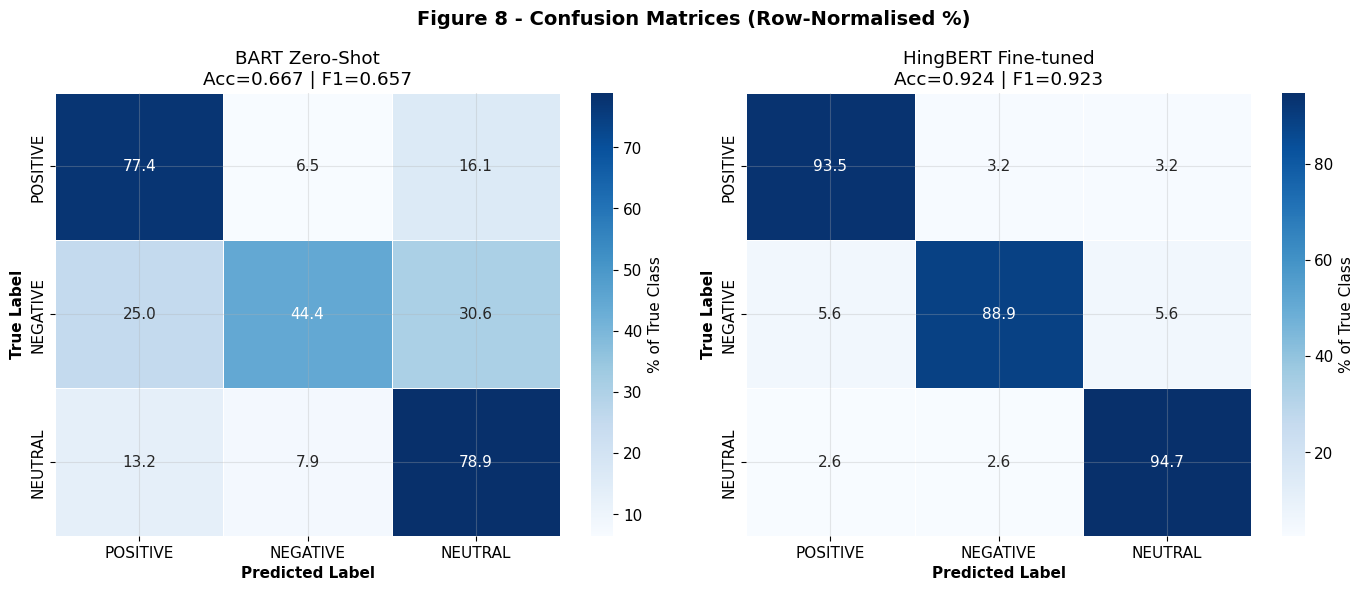

In [ ]:
# Figure 8: Confusion matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Figure 8 - Confusion Matrices (Row-Normalised %)',
             fontsize=14, fontweight='bold')

for ax, preds, title in [
    (axes[0], bart_preds,     f'BART Zero-Shot\nAcc={bart_acc:.3f} | F1={bart_f1:.3f}'),
    (axes[1], hingbert_preds, f'HingBERT Fine-tuned\nAcc={hingbert_acc:.3f} | F1={hingbert_f1:.3f}')
]:
    cm     = confusion_matrix(y_test, preds)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100

    sns.heatmap(
        cm_pct, annot=True, fmt='.1f', cmap='Blues',
        xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES,
        ax=ax, linewidths=0.5, linecolor='white',
        cbar_kws={'label': '% of True Class'}
    )
    ax.set_xlabel('Predicted Label', fontweight='bold')
    ax.set_ylabel('True Label', fontweight='bold')
    ax.set_title(title)

plt.tight_layout()
plt.savefig('fig8_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

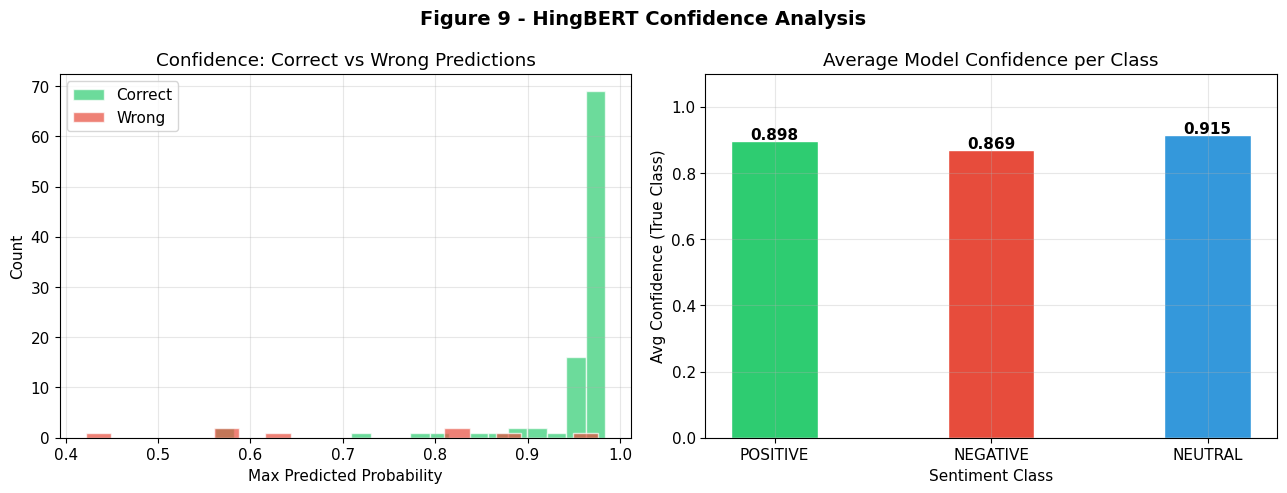

In [ ]:
# Figure 9: Confidence distribution of HingBERT
max_probs  = hingbert_probs.max(axis=1)
pred_labels = [ID2LABEL[p] for p in hingbert_preds]
correct     = (np.array(hingbert_preds) == np.array(y_test))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 9 - HingBERT Confidence Analysis', fontsize=14, fontweight='bold')

# Confidence histogram: correct vs incorrect
axes[0].hist(max_probs[correct],  bins=20, alpha=0.7,
             color='#2ecc71', label='Correct', edgecolor='white')
axes[0].hist(max_probs[~correct], bins=20, alpha=0.7,
             color='#e74c3c', label='Wrong',   edgecolor='white')
axes[0].set_xlabel('Max Predicted Probability')
axes[0].set_ylabel('Count')
axes[0].set_title('Confidence: Correct vs Wrong Predictions')
axes[0].legend()

# Average confidence per class
avg_conf_per_class = {
    ID2LABEL[i]: hingbert_probs[np.array(y_test) == i, i].mean()
    for i in range(3)
}
bars = axes[1].bar(
    avg_conf_per_class.keys(),
    avg_conf_per_class.values(),
    color=[COLORS[l] for l in avg_conf_per_class.keys()],
    width=0.4, edgecolor='white'
)
for bar, val in zip(bars, avg_conf_per_class.values()):
    axes[1].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontweight='bold')
axes[1].set_xlabel('Sentiment Class')
axes[1].set_ylabel('Avg Confidence (True Class)')
axes[1].set_title('Average Model Confidence per Class')
axes[1].set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig('fig9_confidence.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Error Analysis

In [ ]:
# Build error dataframe
error_rows = []
for text, true, pred, probs in zip(X_test, y_test, hingbert_preds, hingbert_probs):
    if true != pred:
        error_rows.append({
            'text':       text,
            'true':       ID2LABEL[true],
            'predicted':  ID2LABEL[pred],
            'confidence': probs.max()
        })

errors_df = pd.DataFrame(error_rows).sort_values('confidence', ascending=False)

print(f'Total errors : {len(errors_df)} / {len(X_test)}  ({100*len(errors_df)/len(X_test):.1f}%)')
print()
print('Error breakdown (True -> Predicted):')
breakdown = errors_df.groupby(['true', 'predicted']).size().reset_index(name='count')
print(breakdown.to_string(index=False))

Total errors : 8 / 105  (7.6%)

Error breakdown (True -> Predicted):
    true predicted  count
NEGATIVE   NEUTRAL      2
NEGATIVE  POSITIVE      2
 NEUTRAL  NEGATIVE      1
 NEUTRAL  POSITIVE      1
POSITIVE  NEGATIVE      1
POSITIVE   NEUTRAL      1


In [ ]:
# High-confidence wrong predictions (hardest mistakes)
print('━' * 80)
print('HIGH-CONFIDENCE ERRORS (model was very sure but wrong):')
print('━' * 80)

high_conf_errors = errors_df[errors_df['confidence'] > 0.8].head(10)

if high_conf_errors.empty:
    print('None (no high-confidence errors found)\n')
else:
    for _, row in high_conf_errors.iterrows():
        print(f'True: {row["true"]:8s}  Pred: {row["predicted"]:8s}  Conf: {row["confidence"]:.3f}')
        print(f'Text: {row["text"]}')
        print()

print('━' * 80)
print('LOW-CONFIDENCE ERRORS (model was uncertain and wrong):')
print('━' * 80)

low_conf_errors = errors_df[errors_df['confidence'] < 0.5].head(10)

if low_conf_errors.empty:
    print('None (no low-confidence errors found)\n')
else:
    for _, row in low_conf_errors.iterrows():
        print(f'True: {row["true"]:8s}  Pred: {row["predicted"]:8s}  Conf: {row["confidence"]:.3f}')
        print(f'Text: {row["text"]}')
        print()

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
HIGH-CONFIDENCE ERRORS (model was very sure but wrong):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
True: NEUTRAL   Pred: POSITIVE  Conf: 0.976
Text: Screen brightness thodi kam hai dhoop mein, baaki sab mast hai.

True: NEGATIVE  Pred: POSITIVE  Conf: 0.882
Text: Bhai, ye toh ekdum 'Original' nakli maal bhej diya aapne, talent toh hai.

True: NEGATIVE  Pred: NEUTRAL   Conf: 0.828
Text: Shirt ki stitching thodi kachi hai side se.

True: NEUTRAL   Pred: NEGATIVE  Conf: 0.812
Text: Refund mil gaya par unhone 15 din laga diye process karne mein.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
LOW-CONFIDENCE ERRORS (model was uncertain and wrong):
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
True: NEGATIVE  Pred: NEUTRAL   Conf: 0.422
Text: Interface itna 'user friendly' hai ki mujhe seekhne ke liye engin

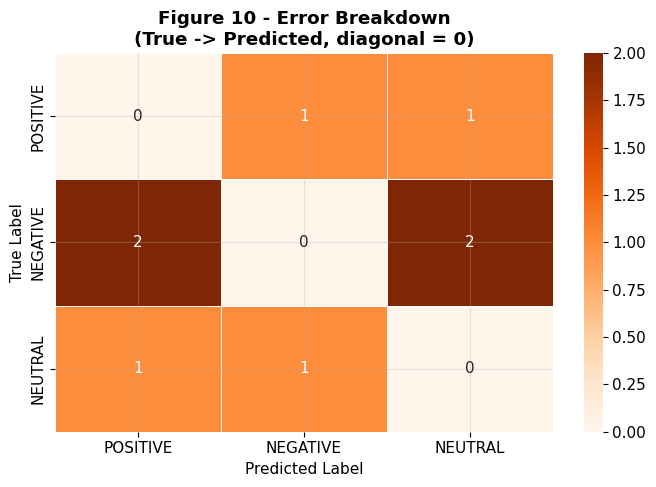

In [ ]:
# Figure 10: Error breakdown heatmap
error_matrix = pd.pivot_table(
    errors_df, values='text', index='true',
    columns='predicted', aggfunc='count', fill_value=0
)
# Ensure all classes present
for c in CLASS_NAMES:
    if c not in error_matrix.columns: error_matrix[c] = 0
    if c not in error_matrix.index:   error_matrix.loc[c] = 0
error_matrix = error_matrix.reindex(index=CLASS_NAMES, columns=CLASS_NAMES, fill_value=0)
np.fill_diagonal(error_matrix.values, 0)  # only errors, no diagonal

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(error_matrix, annot=True, fmt='d', cmap='Oranges',
            linewidths=0.5, linecolor='white', ax=ax)
ax.set_title('Figure 10 - Error Breakdown\n(True -> Predicted, diagonal = 0)',
             fontweight='bold')
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
plt.tight_layout()
plt.savefig('fig10_error_breakdown.png', dpi=150, bbox_inches='tight')
plt.show()

## 11. Save Model & Download All Assets

In [ ]:
SAVE_PATH = './hinglish_sentiment_model'
model.save_pretrained(SAVE_PATH)
tokenizer.save_pretrained(SAVE_PATH)

with open(f'{SAVE_PATH}/label_mappings.json', 'w') as f:
    json.dump({'label2id': LABEL2ID, 'id2label': ID2LABEL}, f)

print(f'Model saved to {SAVE_PATH}/')
!ls -lh {SAVE_PATH}

Model saved to ./hinglish_sentiment_model/
total 419M
-rw-r--r-- 1 root root 1021 May  4 22:29 config.json
-rw-r--r-- 1 root root  122 May  4 22:30 label_mappings.json
-rw-r--r-- 1 root root 418M May  4 22:30 model.safetensors
-rw-r--r-- 1 root root  392 May  4 22:30 tokenizer_config.json
-rw-r--r-- 1 root root 695K May  4 22:30 tokenizer.json


In [ ]:
# Quick inference test
from transformers import pipeline as hf_pipe

sentiment_pipe = hf_pipe(
    'text-classification',
    model=SAVE_PATH,
    tokenizer=SAVE_PATH,
    device=0 if torch.cuda.is_available() else -1,
    top_k=None
)

test_reviews = [
    ('Bahut achha product hai yaar, totally worth it!',         'POSITIVE'),
    ('Bilkul bakwaas quality, waste of money bhai',             'NEGATIVE'),
    ('Theek thaak hai, na bahut achha na bura',                 'NEUTRAL'),
    ('Delivery fast thi but packaging weak lagi',               'NEUTRAL'),
    ('Ekdum bekar product, return karna padha',                 'NEGATIVE'),
    ('Zabardast quality! Paise vasool product hai yeh',         'POSITIVE'),
]

print('═' * 65)
print('INFERENCE TEST - Saved Model')
print('═' * 65)
all_correct = 0
for review, expected in test_reviews:
    scores = sentiment_pipe(review)[0]
    top    = max(scores, key=lambda x: x['score'])
    match  = '✓' if top['label'] == expected else '✗'
    print(f'{match} [{top["label"]:8s} {top["score"]:5.3f}]  {review}')
    if top['label'] == expected:
        all_correct += 1
print(f'\nInference check: {all_correct}/{len(test_reviews)} correct')

═════════════════════════════════════════════════════════════════
INFERENCE TEST - Saved Model
═════════════════════════════════════════════════════════════════
✓ [POSITIVE 0.976]  Bahut achha product hai yaar, totally worth it!
✓ [NEGATIVE 0.885]  Bilkul bakwaas quality, waste of money bhai
✓ [NEUTRAL  0.976]  Theek thaak hai, na bahut achha na bura
✓ [NEUTRAL  0.973]  Delivery fast thi but packaging weak lagi
✓ [NEGATIVE 0.936]  Ekdum bekar product, return karna padha
✓ [POSITIVE 0.976]  Zabardast quality! Paise vasool product hai yeh

Inference check: 6/6 correct


In [ ]:
from huggingface_hub import notebook_login
notebook_login()

HF_REPO = 'Arman-03/sentiment-analysis-hinglish'
model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f'\nModel live at: https://huggingface.co/{HF_REPO}')

No files have been modified since last commit. Skipping to prevent empty commit.



Model live at: https://huggingface.co/Arman-03/sentiment-analysis-hinglish


In [ ]:
# Zip model + download all assets
!zip -r hinglish_sentiment_model.zip hinglish_sentiment_model/

from google.colab import files

assets = [
    'fig1_class_distribution.png',
    'fig2_length_analysis.png',
    'fig3_top_words.png',
    'fig4_wordclouds.png',
    'fig5_wordcloud_overall.png',
    'fig6_split.png',
    'fig7_training_curves.png',
    'fig8_confusion_matrices.png',
    'fig9_confidence.png',
    'fig10_error_breakdown.png',
    'model_comparison.csv',
    'hinglish_sentiment_model.zip'
]

print('Downloading all assets...')
for asset in assets:
    try:
        files.download(asset)
        print(f'  ✓ {asset}')
    except Exception as e:
        print(f'  ✗ {asset} — {e}')

  adding: hinglish_sentiment_model/ (stored 0%)
  adding: hinglish_sentiment_model/config.json (deflated 53%)
  adding: hinglish_sentiment_model/tokenizer.json (deflated 71%)
  adding: hinglish_sentiment_model/label_mappings.json (deflated 37%)
  adding: hinglish_sentiment_model/tokenizer_config.json (deflated 47%)
  adding: hinglish_sentiment_model/model.safetensors (deflated 7%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ fig1_class_distribution.png


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✓ model_comparison.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✓ hinglish_sentiment_model.zip
